# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [19]:
print(df.columns)

Index(['type', 'release_year', 'added_year', 'genre', 'country', 'rating',
       'duration', 'decade'],
      dtype='object')


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


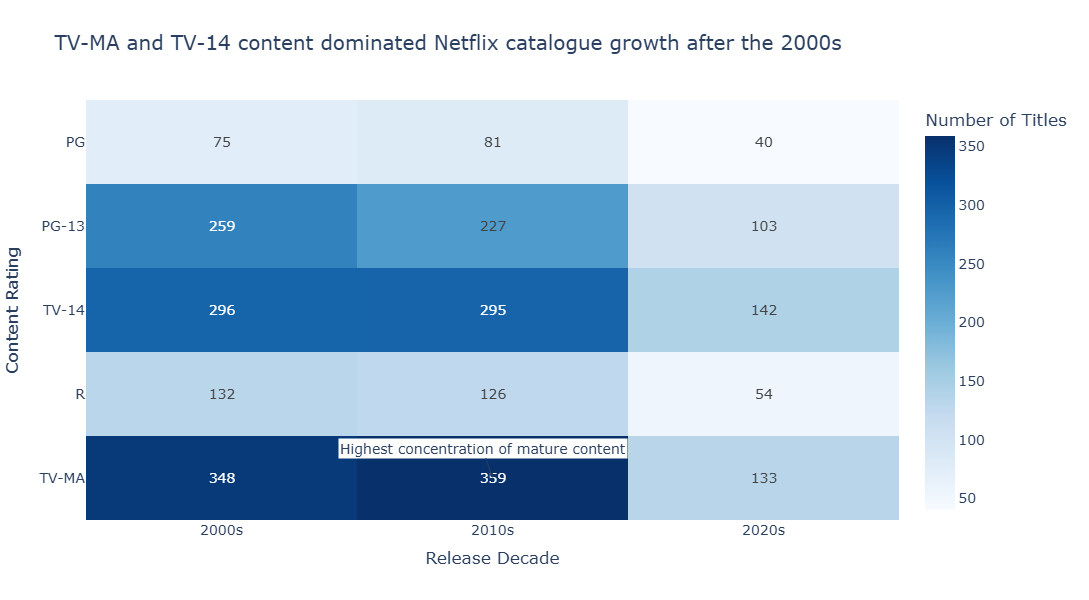

In [16]:
import pandas as pd
import plotly.express as px


# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'


# Filter required ratings

ratings_filter = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

filtered = df[df['rating'].isin(ratings_filter)].copy()

# -----------------------------------
# Group data properly
# -----------------------------------
heatmap_data = filtered.groupby(
    ['rating', 'decade']
).size().reset_index(name='count')

# -----------------------------------
# Pivot table
# -----------------------------------
pivot = heatmap_data.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# -----------------------------------
# Logical rating order
# -----------------------------------
rating_order = ['PG', 'PG-13', 'TV-14', 'R', 'TV-MA']

pivot = pivot.reindex(rating_order)

# -----------------------------------
# Create heatmap
# -----------------------------------
fig = px.imshow(
    pivot,
    color_continuous_scale='Blues',
    text_auto=True,
    aspect='auto',
    title='TV-MA and TV-14 content dominated Netflix catalogue growth after the 2000s'
)

# -----------------------------------
# Layout styling
# -----------------------------------
fig.update_layout(
    width=1000,
    height=600,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=14),
    title_font=dict(size=20),
    xaxis_title='Release Decade',
    yaxis_title='Content Rating',
    coloraxis_colorbar=dict(title='Number of Titles')
)

# -----------------------------------
# Annotation
# -----------------------------------
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Highest concentration of mature content',
    showarrow=True,
    arrowhead=2,
    bgcolor='white'
)

fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


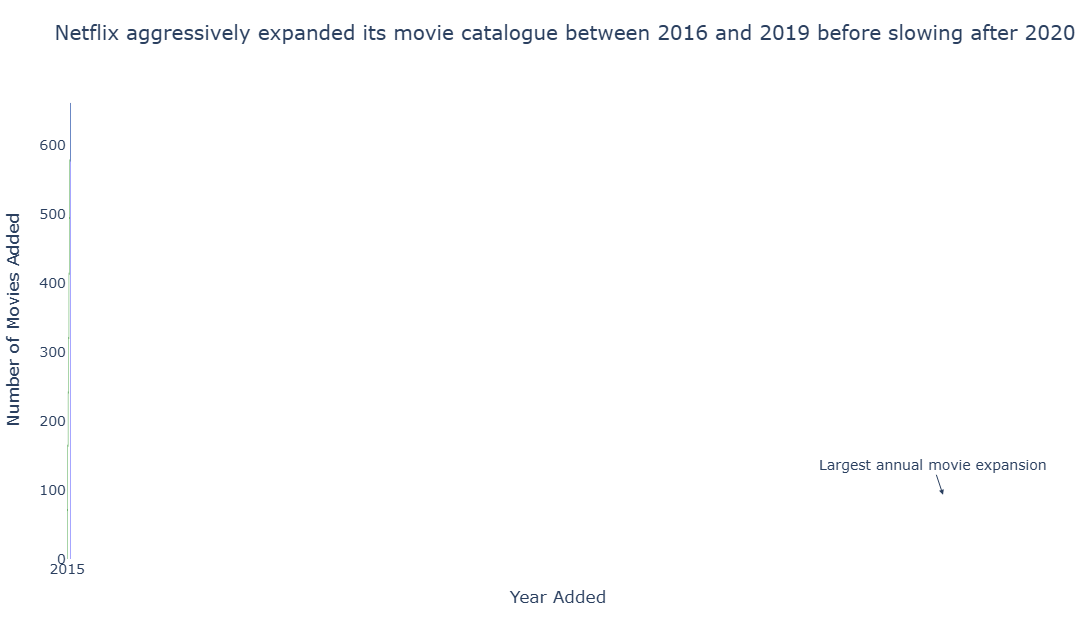

In [17]:

# Filter Movies only
# -----------------------------------
movies = df[df['type'] == 'Movie'].copy()

# -----------------------------------
# Group by added year
# -----------------------------------
adds = movies.groupby(
    'added_year'
).size().reset_index(name='new_titles')

# -----------------------------------
# Filter years 2015-2022
# -----------------------------------
adds = adds[
    (adds['added_year'] >= 2015) &
    (adds['added_year'] <= 2022)
]

# -----------------------------------
# Calculate cumulative total
# -----------------------------------
cumulative_total = adds['new_titles'].sum()

# -----------------------------------
# Find maximum year
# -----------------------------------
max_row = adds.loc[adds['new_titles'].idxmax()]

max_year = str(max_row['added_year'])
max_value = max_row['new_titles']

# -----------------------------------
# Create waterfall chart
# -----------------------------------
fig = go.Figure(go.Waterfall(

    x=adds['added_year'].astype(str).tolist() + ['Total Catalogue Growth'],

    y=adds['new_titles'].tolist() + [cumulative_total],

    measure=['relative'] * len(adds) + ['total'],

    text=adds['new_titles'].astype(str).tolist() + [str(cumulative_total)],

    textposition='outside',

    connector={'line': {'color': 'gray'}},

    increasing={'marker': {'color': 'green'}},

    decreasing={'marker': {'color': 'red'}},

    totals={'marker': {'color': 'blue'}}

))

# -----------------------------------
# Layout styling
# -----------------------------------
fig.update_layout(
    title='Netflix aggressively expanded its movie catalogue between 2016 and 2019 before slowing after 2020',
    width=1100,
    height=600,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=14),
    title_font=dict(size=20),
    xaxis_title='Year Added',
    yaxis_title='Number of Movies Added',
    showlegend=False,
    margin=dict(t=80, l=60, r=40, b=60)
)

# -----------------------------------
# Annotation
# -----------------------------------
fig.add_annotation(
    x=max_year,
    y=max_value,
    text='Largest annual movie expansion',
    showarrow=True,
    arrowhead=2,
    bgcolor='white'
)

fig.show()